# 1. Import Libraries


In [4]:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import pickle
import joblib

# 2. Load Dataset


In [5]:
df = pd.read_csv("UP_rainfall_dataset.csv")

print(df.shape)
df.head()


(565210, 20)


,YEAR,MO,DY,RH2M,T2MDEW,QV2M,PS,WS50M,PRECTOTCORR,T2MWET,WD50M,T2M_MAX,T2M_MIN,ALLSKY_SFC_UV_INDEX,TS,PSC,WSC,DISTRICT,LATITUDE,LONGITUDE
0,2005,1,1,56.63,9.67,7.63,99.55,3.66,0.34,14.17,135.7,26.69,14.08,0.41,19.15,90.24,5.07,Agra,27.17,78.04
1,2005,1,2,57.34,8.98,7.23,99.60,2.36,0.01,13.76,157.3,26.16,11.26,0.46,17.76,90.29,3.27,Agra,27.17,78.04
2,2005,1,3,55.19,6.25,6.12,99.79,4.27,0.33,11.35,338.1,24.76,10.65,0.32,16.40,90.39,5.91,Agra,27.17,78.04
3,2005,1,4,44.92,0.88,4.06,100.10,4.69,0.00,7.28,327.9,23.37,6.56,0.62,13.72,90.58,6.50,Agra,27.17,78.04
4,2005,1,5,45.51,0.88,4.07,99.94,4.05,0.00,7.24,338.2,23.25,5.76,0.65,13.55,90.43,5.61,Agra,27.17,78.04


# 3. Data Cleaning & Imputation


In [6]:
# Check null values
print(df.isnull().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

# Fill missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

YEAR                   0
MO                     0
DY                     0
RH2M                   0
T2MDEW                 0
QV2M                   0
PS                     0
WS50M                  0
PRECTOTCORR            0
T2MWET                 0
WD50M                  0
T2M_MAX                0
T2M_MIN                0
ALLSKY_SFC_UV_INDEX    0
TS                     0
PSC                    0
WSC                    0
DISTRICT               0
LATITUDE               0
LONGITUDE              0
dtype: int64


# 4. Feature Engineering


In [7]:
# Create new feature
df["DATE"] = pd.to_datetime(
    df[["YEAR", "MO", "DY"]]
    .rename(columns={
        "YEAR":"year",
        "MO":"month",
        "DY":"day"
    })
)

df["MONTH"] = df["DATE"].dt.month
df["DAY_OF_YEAR"] = df["DATE"].dt.dayofyear
df["SEASON"] = (df["MONTH"] % 12 + 3) // 3

df["TEMP_RANGE"] = df["T2M_MAX"] - df["T2M_MIN"]

df["HUMIDITY_DEW_DIFF"] = (
    df["RH2M"] - df["T2MDEW"]
)

df["WIND_INTENSITY"] = (
    df["WS50M"] * df["WSC"]
)

# 5. Data Visualization


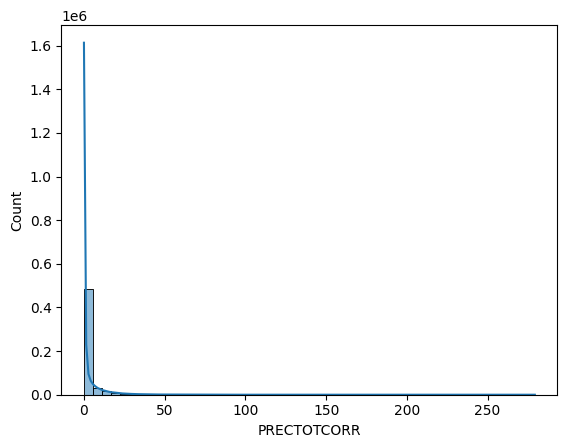

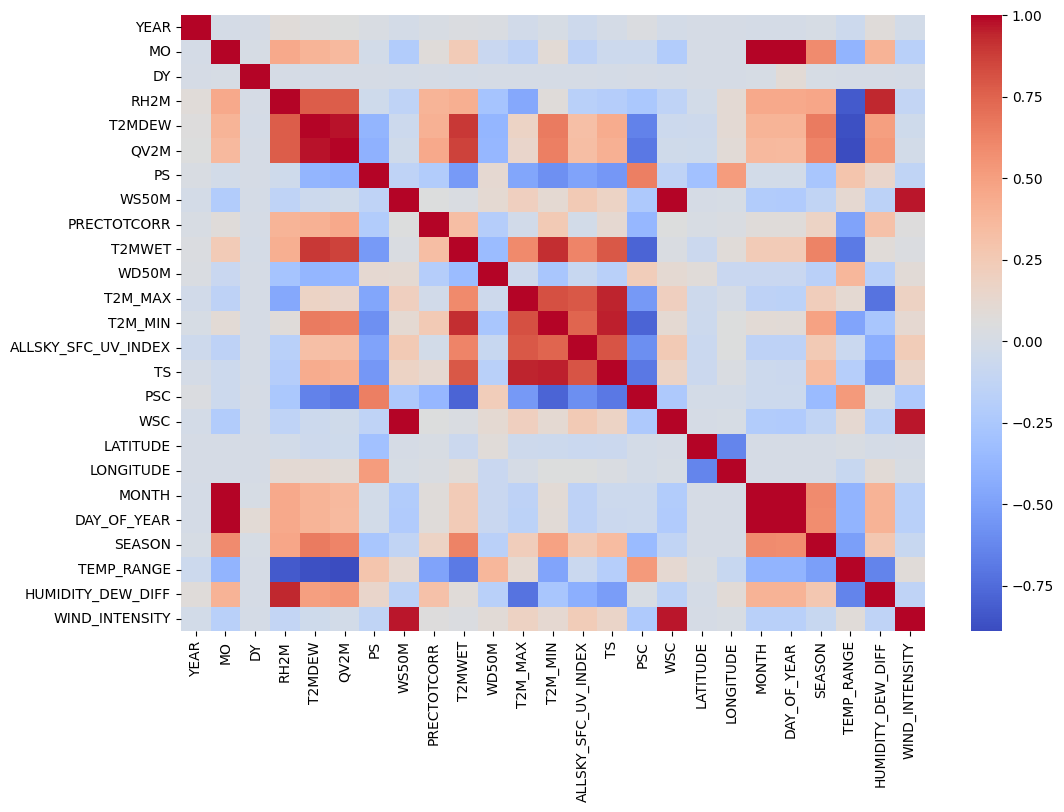

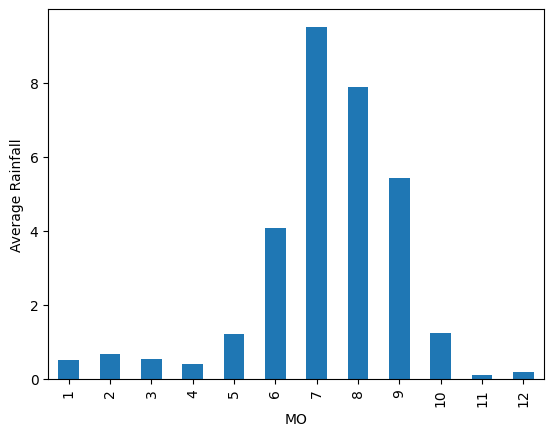

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    df["PRECTOTCORR"],
    bins=50,
    kde=True
)

plt.show()

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.show()

monthly = df.groupby("MO")["PRECTOTCORR"].mean()

monthly.plot(kind="bar")

plt.ylabel("Average Rainfall")
plt.show()

# 6. Categorical Encoding


In [9]:
# Encode categorical column
df = pd.get_dummies(df, columns=['DISTRICT'], drop_first=True)

print("Remaining object columns:")
print(df.select_dtypes(include=['object']).columns)


Remaining object columns:
Index([], dtype='object')


# 7. Train-Test Split


In [10]:
# Features and target
X = df.drop(columns=['PRECTOTCORR'])

if 'DATE' in X.columns:
    X = X.drop(columns=['DATE'])

y = df['PRECTOTCORR']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.select_dtypes(include=['object']).columns)


Index([], dtype='object')


# 8. Model Initialization


In [11]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# 9. Model Training (Random Forest Regressor)


In [12]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model trained successfully")


Model trained successfully


# 10. Model Evaluation (MAE, R²)


In [13]:
from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("R2 :", r2_score(y_test, pred))

MAE: 1.2563163251580507
R2 : 0.7685393414886373


# 11. Debugging & Feature Verification


In [14]:
print("Object columns in X_train:")
print(X_train.select_dtypes(include=['object']).columns)

print("\nObject columns in df:")
print(df.select_dtypes(include=['object']).columns)

Object columns in X_train:
Index([], dtype='object')

Object columns in df:
Index([], dtype='object')


In [15]:
# Debug cell no longer needed
print("Object columns:", X_train.select_dtypes(include=['object']).columns.tolist())


Object columns: []


# 12. Full Pipeline Re-verification


In [16]:
import pandas as pd

# Load dataset again
df = pd.read_csv("UP_rainfall_dataset.csv")

# Feature engineering
df["DATE"] = pd.to_datetime(
    df[["YEAR","MO","DY"]].rename(
        columns={"YEAR":"year","MO":"month","DY":"day"}
    )
)

df["MONTH"] = df["DATE"].dt.month
df["DAY_OF_YEAR"] = df["DATE"].dt.dayofyear
df["SEASON"] = (df["MONTH"] % 12 + 3) // 3

df["TEMP_RANGE"] = df["T2M_MAX"] - df["T2M_MIN"]
df["HUMIDITY_DEW_DIFF"] = df["RH2M"] - df["T2MDEW"]
df["WIND_INTENSITY"] = df["WS50M"] * df["WSC"]

# Encode district
df = pd.get_dummies(df, columns=["DISTRICT"], drop_first=True)

# Remove date
X = df.drop(columns=["PRECTOTCORR", "DATE"])
y = df["PRECTOTCORR"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.select_dtypes(include=['object']).columns)

Index([], dtype='object')


# 13. Model & Feature Export (joblib)


In [17]:
import joblib

# 1. Export your trained Random Forest Regressor model
# (Your notebook instantiates and defines this as 'model')
joblib.dump(model, 'rainfall_rf_model.joblib')

# 2. Export the final list of columns/features expected by your model
# (Since 'X_train' is what your model was trained on)
model_features = list(X_train.columns)
joblib.dump(model_features, 'model_features.joblib')

print("✅ Both 'rainfall_rf_model.joblib' and 'model_features.joblib' successfully exported!")

✅ Both 'rainfall_rf_model.joblib' and 'model_features.joblib' successfully exported!
